# Imports

In [6]:
import os
import sys

In [7]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [9]:
# frank2d
from frank2d import *

# frank1d
from frank.utilities import UVDataBinner

## Functions

In [10]:
def calculate_resolution( clean_beam, current_beam):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - current_beam**2)
    final_bmin_as = np.sqrt(bmin_as**2 - current_beam**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [11]:
def calculate_resolution2( clean_beam, current_beam):
    from radio_beam import Beam
    bmaj_clean = clean_beam['bmaj']
    bmin_clean = clean_beam['bmin']
    bpa_deg_clean = clean_beam['beam_pa']

    bmaj_current = current_beam['bmaj']
    bmin_current = current_beam['bmin']
    bpa_deg_current = current_beam['beam_pa']

    beam_orig =  Beam(major=bmaj_current*u.arcsec, minor=bmin_current*u.arcsec, pa=bpa_deg_current)
    beam_target = Beam(major=bmaj_clean*u.arcsec, minor=bmin_clean*u.arcsec, pa=bpa_deg_clean)

    beam_final = beam_target.deconvolve(beam_orig)

    #return values in a dict
    final_resolution = {'bmaj': beam_final.major.to(u.arcsec).value,
                        'bmin': beam_final.minor.to(u.arcsec).value,
                        'beam_pa': beam_final.pa.to(u.deg).value}

    return final_resolution


In [12]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [13]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

In [14]:
def create_disk_image_blob_jy_per_pixel(
    N=500,                         # Image size (N x N pixels)
    pixel_scale_arcsec=0.01,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.4, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.05, 0.02, 0.05], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=0.1,                  # Core amplitude (Jy/pixel)
    amp_rings=[0.05, 0.04, 0.03],  # Rings amplitude (Jy/pixel)
    m_modes=[1, 0, 0],             # Asymmetry mode (1 -> blob, 0 -> ring)
    theta0=[np.pi, 0, 0],     # Blob position angle (radians)
    amp_asym=[0.9, 0, 0]           # Asymmetry/blob amplitude (fraction of amp_rings)
):
    """
    Creates a synthetic disk image directly in Jy/pixel by summing
    Gaussian and annular components in the image plane.
    """
    
    # 1. Prepare coordinate grid and radii
    
    # Pixel coordinates (in arcsec, with center at (0, 0))
    x_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    y_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    
    # Create the 2D grid of coordinates and radii
    X, Y = np.meshgrid(x_arcsec, y_arcsec)
    R_image = np.sqrt(X**2 + Y**2)
    Phi_image = np.arctan2(Y, X) # Polar angle of each pixel
    
    # Initialize the total image in Jy/pixel
    I_disk_jy_per_pixel = np.zeros((N, N))
    
    # 2. Add the Central Gaussian Core
    
    # 2D Gaussian Formula: I(r) = A * exp(- (r^2 / (2 * sigma^2)))
    # Note: Your original code uses exp(-2 * (pi * sigma * baseline)^2), 
    # which is the FT of a Gaussian. In the image plane, we use the standard form:
    sigma_image = sigma_core / np.sqrt(2 * np.log(2)) # Approximation FWHM -> sigma (Commented out line, original uses sigma_core directly)
    
    I_core = amp_core * np.exp(-0.5 * (R_image / sigma_core)**2)
    I_disk_jy_per_pixel += I_core
    
    # 3. Add Rings and Blobs
    
    # Iterate over the properties of each component
    for A, R, w, w_blob, m, th0, Aasym in zip(amp_rings, R_rings,
                                              width_rings, width_blobs,
                                              m_modes, theta0, amp_asym):
        
        # Symmetric Ring (Gaussian centered at radius R)
        # Formula: I(r) = A * exp(-(r - R)^2 / (2 * w^2))
        I_ring = A * np.exp(-0.5 * ((R_image - R) / w)**2)
        I_disk_jy_per_pixel += I_ring
        
        # Asymmetric Blobs (Displaced Gaussian)
        if m != 0 and Aasym > 0:
            
            # Blob center position (in arcsec)
            x0 = R * np.cos(th0)
            y0 = R * np.sin(th0)
            
            # Coordinate offset
            X_blob = X - x0
            Y_blob = Y - y0
            R_blob_sq = X_blob**2 + Y_blob**2
            
            # Blob amplitude (fraction of the ring)
            A_blob = Aasym * A
            
            # Blob Gaussian (centered at (x0, y0))
            I_blob = A_blob * np.exp(-0.5 * (R_blob_sq / w_blob**2))
            
            I_disk_jy_per_pixel += I_blob
            
    return I_disk_jy_per_pixel

# Data

In [15]:
# UVtable
dir = "../../data/uvtable/"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Load data
file = np.loadtxt(data_file, unpack = True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j

In [16]:
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

In [17]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [18]:
Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


In [19]:
imsize = N

In [20]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [21]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [22]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
best_N100 = {'m': -2.935881163664834, 'c': 79471204676386.11, 'l': 45256.57763586783}

In [23]:
best = best_N100

In [24]:
FWHM_frank2d_N100= 0.02276732753216587
FWHM_frank2d_N50 = 0.02246119946612007
FWHM_frank2d = FWHM_frank2d_N100

In [25]:
frank2d = Frank2D(N, Rmax)

In [26]:
start_time = time.time()
frank2d.fit(data = uvtable, kernel_params = best, rtol = 1e-10 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.935881163664834, 'c': 79471204676386.11, 'l': 45256.57763586783}
===>  Creating sparse linear system...
        +  Kernel = 0.02  min |  1.27 seconds
        +  Building system = 0.02  min |  1.31 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 231/50000 [00:16<58:22, 14.21 iterations/s]  


            +  BiCGStab = 0.27  min |  16.33 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417658,
 'iterations': 231,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.09  min |  5.40 seconds
--> times building full visibility model = 0.09  min |  5.42 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 642 took 25.467370748519897 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [27]:
Plot_ = Plot(frank2d, geom_f2d)

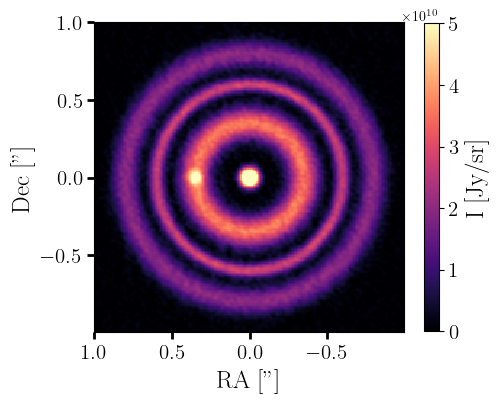

In [28]:
Plot_.intensity(gamma=1, zoom=3, vmax = 5e10, title="", fig_size=5, 
tick_label_size = 15, label_size = 18, title_size = 18)

### Open fits file
Of image regridded in CASA with imregrid, the same image from where we got the CLEAN model uvtable.

In [29]:
from astropy.io import fits
dir_  = "../../data/.image_fits/"
disk = 'SimulatedBlob_dotimage_imsize642_cellsize0p009.fits'

fits_name = dir_ + disk

In [30]:
hdul = fits.open(fits_name)

In [31]:
import matplotlib.colors as colors

### CLEAN model imregridded

In [32]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [33]:
hdr = hdul[0].header
data = hdul[0].data 

In [34]:
# beam
bmaj = hdr.get('BMAJ') # degrees
bmaj_as = bmaj * 3600 # arcseconds
bmin = hdr.get('BMIN')
bmin_as = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [35]:
w = WCS(hdr)

In [36]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 642, 642) -> squeezed: (642, 642)


In [37]:
data = data_squeezed

In [38]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [39]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



In [40]:
xmax

np.float64(3.000011178876008)

In [41]:
cellsize_clean = np.abs(ra_off_arcsec[0][1]-ra_off_arcsec[0][0])
cellsize_clean

np.float64(0.00934582909954429)

In [42]:
pixel_scale_x_as = cellsize_clean
pixel_scale_y_as = cellsize_clean

bmaj_pix = bmaj_as/pixel_scale_x_as
bmin_pix = bmin_as/pixel_scale_y_as
angle_display = 90.0 - bpa 

In [43]:
Rmax*2 / imsize  

0.009345794392523364

In [44]:
xmax

np.float64(3.000011178876008)

In [45]:
bmin_as, bmaj_as

(0.0300071798264988, 0.044606443494563996)

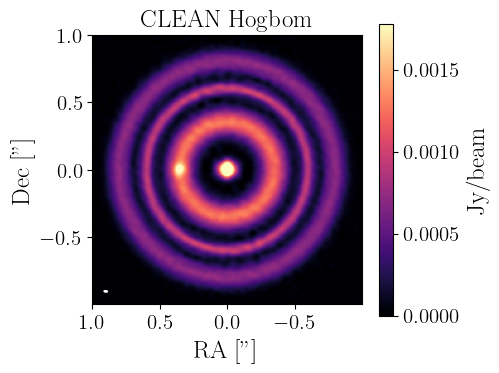

In [46]:
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(5,5))
norm = colors.PowerNorm(gamma=1, vmin=0, vmax = img.max()/2)
ax = plt.gca()

im = ax.imshow(
    img,
    extent=[xmax, xmin, ymax, ymin],
    aspect='equal',
    cmap='magma',
    norm=norm,
)


ax.set_xlabel('RA ["]', size=18)
ax.set_ylabel('Dec ["]', size=18)
ax.set_xlim(xmax/3, xmin/3)
ax.set_ylim(ymax/3, ymin/3)
ax.set_title(r'CLEAN Hogbom', size=18)
plt.tick_params(axis='both', labelsize=15)

cbar = plt.colorbar(im, ax=ax, shrink=0.65)
cbar.set_label( hdr.get('BUNIT'), size=18)
cbar.ax.tick_params(labelsize=15)
cbar.update_ticks()
ax.grid(False)

xloc = xmin + 0.5 * (xmax - xmin)
yloc = ymin + 0.5 * (ymax - ymin)


beam = patches.Ellipse(
    (0.9, -0.9), 
    width=bmaj_as, 
    height=bmin_as, 
    angle=angle_display, 
    facecolor='white', 
    edgecolor='black', 
    linewidth=0.8, 
    zorder=5
)

ax.add_patch(beam)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Comparing with the ground thruth

In [47]:
N = frank2d.Nx
dx = frank2d.dx # arcsec
dxy = dx/rad_to_arcsec
type_ ="Blob"
amp_core_ajustado = 0.00025 
amp_rings_ajustado = [0.000086, 0.000070, 0.000050] 
amp_asym_ajustado = [0.65, 0, 0]

reference_image = create_disk_image_blob_jy_per_pixel(
    N=N,                         # Image size (N x N pixels)
    pixel_scale_arcsec=dx,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.35, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.07, 0.03, 0.06], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=amp_core_ajustado,    # Core amplitude (Jy/pixel)
    amp_rings=amp_rings_ajustado,  # Rings amplitude (Jy/pixel)
    amp_asym=amp_asym_ajustado,
    theta0=[np.pi, 0, 0],
    m_modes=[1, 0, 0])

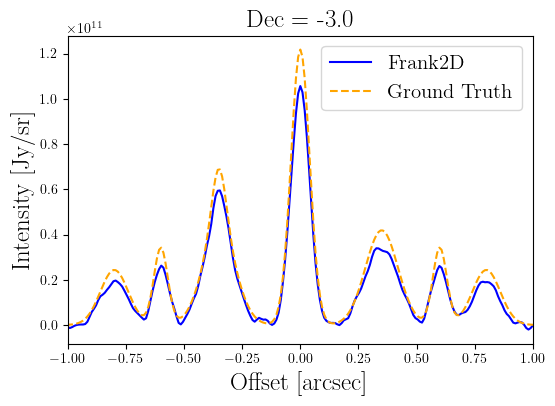

In [48]:
y = frank2d.N//2

#frank2d
I_f2d = frank2d.intensity_model[y]
x = frank2d.x_grid[0]*rad_to_arcsec
y_i = frank2d.y_grid[0][y]*rad_to_arcsec

# Cálculo del área sólida (en sr)
sigma_sr =  (dx/rad_to_arcsec)**2
image_jy_per_sr = reference_image / sigma_sr
I_ground_truth = image_jy_per_sr[y]

plt.figure(figsize=(6,4))
plt.plot(x, I_f2d, label='Frank2D', color='blue')
plt.plot(x, I_ground_truth, label='Ground Truth', color='orange', linestyle='dashed')
plt.xlabel('Offset [arcsec]', size=18)
plt.ylabel('Intensity [Jy/sr]', size=18)
plt.title('Dec = ' + str(y_i), size=18)
plt.legend(fontsize=15)
plt.xlim(-rout, rout)
plt.show()

In [49]:
indices_seleccionados = [
    int(N/2 - 80),
    int(N/2 - 30),  
    int(N/2 - 10), 
    int(N/2 - 5), 
    int(N/2), 
    int(N/2 + 8),
    int(N/2 + 20),  # Nuevo índice 7
    int(N/2 + 40),  # Nuevo índice 8
    int(N/2 + 60)   # Nuevo índice 9
]


sigma_sr = (dx / rad_to_arcsec)**2
image_jy_per_sr = reference_image / sigma_sr

fig, axes = plt.subplots(3, 3, figsize=(9, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(indices_seleccionados):
        ax.axis('off')
        continue
        
    idx = indices_seleccionados[i]

    I_f2d = frank2d.intensity_model[idx]
    x = frank2d.x_grid[0] * rad_to_arcsec
    y_i = frank2d.y_grid[idx][0] * rad_to_arcsec
    I_ground_truth = image_jy_per_sr[idx]

    ax.plot(x, I_f2d, label='Frank2D', color='magenta')
    ax.plot(x, I_ground_truth, label='Ground Truth', color='blue', linestyle='dashed')
    
    ax.set_title(f' Dec = {y_i:.2f}"', size=13)
    ax.set_xlim(-rout, rout)

    # increase fontsize ticks
    ax.tick_params(axis='both', which='both', labelsize=13)

    ax.axvline(-0.35, color='gray', linestyle='--', linewidth=0.8, label=r"blob")
    ax.axvline(-0.49, color='gray', linestyle='dotted', linewidth=0.8, label="gap")
    ax.axvline(-0.6, color='gray', linestyle='-', linewidth=0.8, label="ring")
    ax.axvline(-0.68, color='gray', linestyle='dotted', linewidth=0.8,)
    ax.axvline(-0.8, color='gray', linestyle='-', linewidth=0.8)

    
    if i % 3 == 0:
        ax.set_ylabel('Intensity [Jy/sr]', size=14)
    
    if i >= 6:
        ax.set_xlabel('Radius [arcsec]', size=14)
    
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

#
plt.tight_layout()
plt.show()

### 1D Profile

In [ ]:
f2d = frank2d
geom = geom_f2d
inc, pa, dra, ddec = geom.inc, geom.pa, geom.dra, geom.ddec

In [ ]:
from gofish import imagecube
cube_1mm = imagecube(fits_name)
x_clean, y_clean, dy_clean = cube_1mm.radial_profile(inc= inc, PA=pa, x0=dra, y0=ddec)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


In [ ]:
beam_frank2d = {'bmaj': FWHM_frank2d, 'bmin': FWHM_frank2d, 'beam_pa': 0}
beam_clean = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': hdr['BPA']}
final_beam_f2d = calculate_resolution2( beam_clean, beam_frank2d)

In [ ]:
fits_image = fits.open(fits_name)
header = fits_image[0].header
bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bmaj_as = bmaj_deg * 3600.0
bmin_as = bmin_deg * 3600.0
bpa_deg = header['BPA']

clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2
area = clean_area
print(f"Clean beam: {bmaj_as} x {bmin_as} arcsec")

beam_for_f2d = calculate_resolution(clean_beam, FWHM_frank2d)
beam_for_f2d = final_beam_f2d

Clean beam: 0.044606443494563996 x 0.0300071798264988 arcsec
-> Final beam to convolve with: 0.03835861830510599 x 0.01954685750147369 arcsec


In [ ]:
# f2d model
u_model = f2d.u_grid
v_model = f2d.v_grid
vis_model = f2d.visibility_model

u_model_1d = f2d.u
v_model_1d = f2d.v

x_model = f2d.x_grid * rad_to_arcsec
y_model = f2d.y_grid * rad_to_arcsec

x_model_1d = f2d.x * rad_to_arcsec
y_model_1d = f2d.y * rad_to_arcsec

        
# phase shift
vis = geom.apply_phase_shift(-u_model, -v_model, vis_model) # the East of North convention.
I = f2d.transform(vis).real

# deproject
x_model, y_model = geom.deproject_xy(x_model, y_model)
x_model_1d_d, y_model_1d_d = geom.deproject_xy(x_model_1d, y_model_1d)

# collocation points for the plot.
r = np.unique(np.hypot(x_model_1d_d, y_model_1d_d))
bins = 3*N
r = np.linspace(r.min(), r.max(), bins)
edges_ = edges(r)


r_model_1d, I_model_1d = get_profile(x_model, y_model, I, bins = edges_)
I_model_1d = np.nan_to_num(I_model_1d, nan=0)

In [ ]:
from frank.utilities import convolve_profile
I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, beam_for_f2d)
I_model_1d_convolved *= area # Jy/beam

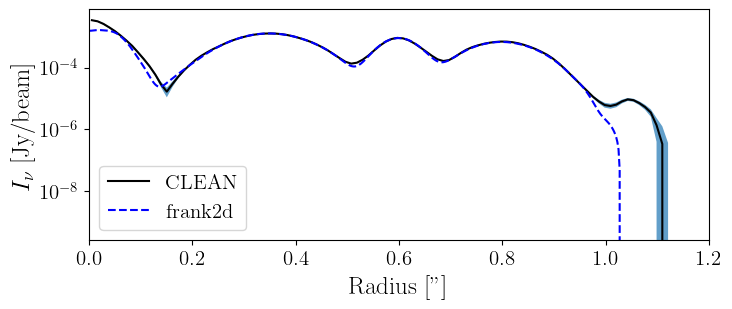

In [ ]:
plt.figure(figsize=(8,3))
#  CLEAN --------------------------------------------------------------------
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
# frank2D -------------------------------------------------------------------
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'frank2d')

plt.ylabel(r'$I_\nu$ [Jy/beam]', size=18)
plt.xlabel('Radius ["]', size=18)
plt.legend(fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.yscale('log')
#plt.title(f'Convolving Frank2D with FWHM beam: {FWHM_frank2d:.3f} x {FWHM_frank2d:.3f} arcsec')
plt.xlim(0, 1.2)
#plt.ylim(1e-7, 0.5e-2)
plt.show()

### Radial cuts

In [ ]:
beam_for_f2d = calculate_resolution(clean_beam, FWHM_frank2d)


FWHM_ground = 0
beam_for_ground = calculate_resolution(clean_beam, FWHM_ground)

-> Final beam to convolve with: 0.03835861830510599 x 0.01954685750147369 arcsec
-> Final beam to convolve with: 0.044606443494563996 x 0.0300071798264988 arcsec


In [ ]:
from frank.utilities import convolve_profile
I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, beam_for_f2d)
I_model_1d_convolved *= area # Jy/beam

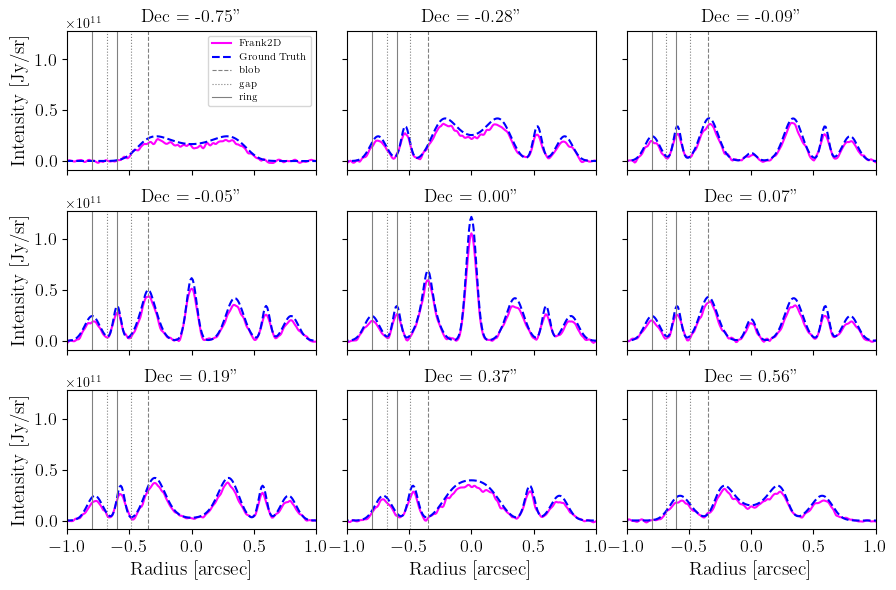

In [ ]:
indices_seleccionados = [
    int(N/2 - 80),
    int(N/2 - 30),  
    int(N/2 - 10), 
    int(N/2 - 5), 
    int(N/2), 
    int(N/2 + 8),
    int(N/2 + 20),  # Nuevo índice 7
    int(N/2 + 40),  # Nuevo índice 8
    int(N/2 + 60)   # Nuevo índice 9
]


sigma_sr = (dx / rad_to_arcsec)**2
image_jy_per_sr = reference_image / sigma_sr

fig, axes = plt.subplots(3, 3, figsize=(9, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(indices_seleccionados):
        ax.axis('off')
        continue
        
    idx = indices_seleccionados[i]

    I_f2d = frank2d.intensity_model[idx]
    x = frank2d.x_grid[0] * rad_to_arcsec

    y_i = frank2d.y_grid[idx][0] * rad_to_arcsec
    I_ground_truth = image_jy_per_sr[idx]


    I_clean =  img[idx]

    ax.plot(x, I_f2d, label='Frank2D', color='magenta')
    ax.plot(x, I_ground_truth, label='Ground Truth', color='blue', linestyle='dashed')
    
    ax.set_title(f' Dec = {y_i:.2f}"', size=13)
    ax.set_xlim(-rout, rout)

    # increase fontsize ticks
    ax.tick_params(axis='both', which='both', labelsize=13)

    ax.axvline(-0.35, color='gray', linestyle='--', linewidth=0.8, label=r"blob")
    ax.axvline(-0.49, color='gray', linestyle='dotted', linewidth=0.8, label="gap")
    ax.axvline(-0.6, color='gray', linestyle='-', linewidth=0.8, label="ring")
    ax.axvline(-0.68, color='gray', linestyle='dotted', linewidth=0.8,)
    ax.axvline(-0.8, color='gray', linestyle='-', linewidth=0.8)

    
    if i % 3 == 0:
        ax.set_ylabel('Intensity [Jy/sr]', size=14)
    
    if i >= 6:
        ax.set_xlabel('Radius [arcsec]', size=14)
    
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

#
plt.tight_layout()
plt.show()

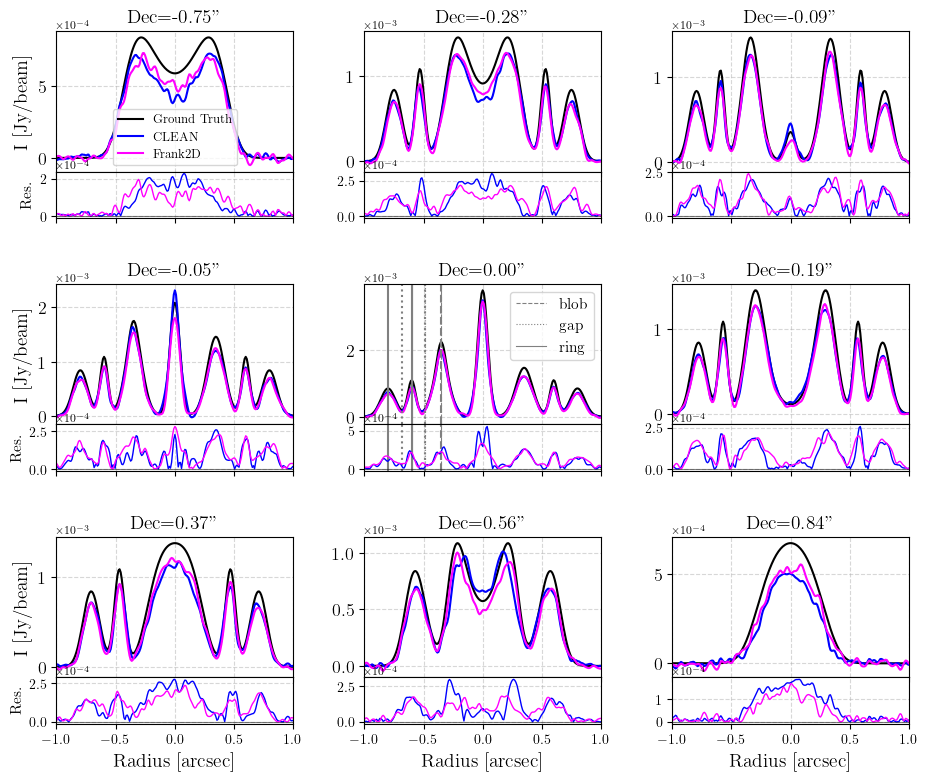

TABLA COMPARATIVA FINAL (CORRECTAMENTE CONVOLUCIONADA)
Dec (")  NRMSE F (%)  NRMSE C (%) Mejor NRMSE  FluxRec F (%)  FluxRec C (%)
  -0.75     6.089632     6.936152       Frank      81.674726      81.662418
  -0.28     4.906869     5.510034       Frank      82.876950      84.065865
  -0.09     4.300798     4.059671       CLEAN      81.267861      84.960239
  -0.05     3.367675     3.000522       CLEAN      82.290118      88.489254
   0.00     2.054598     2.388545       Frank      83.687432      84.800186
   0.19     4.538372     4.300773       CLEAN      81.682253      86.586555
   0.37     4.894377     5.859806       Frank      82.355111      81.429719
   0.56     5.097197     5.926987       Frank      82.754591      87.774656
   0.84     5.648558     7.630858       Frank      79.692571      70.095068

------------------------------------------------------------------------------------------
NRMSE Promedio Global Frank2D : 4.54%
NRMSE Promedio Global CLEAN   : 5.07%
-----------------

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter

# ==============================================================================
# DATOS DE ENTRADA (ASEGÚRATE DE QUE ESTOS VALORES SEAN LOS DE TU IMAGEN CLEAN)
# ==============================================================================
bmaj_clean = bmaj_as
bmin_clean = bmin_as

# Resolución nativa de Frank
fwhm_frank = 22.5e-3 # arcsec

# --- 1. Definición de Índices ---
indices_seleccionados = [
    int(N/2 - 80), int(N/2 - 30), int(N/2 - 10), 
    int(N/2 - 5),  int(N/2),      int(N/2 + 20),
    int(N/2 + 40), int(N/2 + 60), int(N/2 + 90)
]

# --- 2. Preparación de Datos Base ---
sigma_sr = (dx / rad_to_arcsec)**2
image_jy_per_sr = np.nan_to_num(reference_image / sigma_sr, nan=0.0)
frank_model_clean = np.nan_to_num(frank2d.intensity_model, nan=0.0)

pixel_scale_arcsec = (frank2d.x_grid[0][1] - frank2d.x_grid[0][0]) * rad_to_arcsec

# --- 3. CONVOLUCIÓN 2D (CORREGIDA: SUMA EN CUADRATURA) ---

# A) Calculamos el FWHM geométrico del CLEAN Beam
fwhm_clean_geom = np.sqrt(bmaj_clean * bmin_clean)

# B) Definimos el Área del Beam CLEAN (Target final)
# Esto es necesario para pasar de Jy/sr a Jy/beam correctamente
beam_area_clean = (np.pi * (bmaj_clean/rad_to_arcsec) * (bmin_clean/rad_to_arcsec)) / (4 * np.log(2))

# --- Preparar Ground Truth (Resolución infinita -> Clean Beam) ---
sigma_pixels_gt = fwhm_clean_geom / (2.35482 * pixel_scale_arcsec)
I_gt_convolved_2d = gaussian_filter(image_jy_per_sr, sigma=sigma_pixels_gt)
I_gt_convolved_2d *= beam_area_clean 

# --- Preparar Frank2D (Resolución Frank -> Clean Beam) ---
# Kernel^2 = Clean^2 - Frank^2
if fwhm_clean_geom > fwhm_frank:
    fwhm_kernel_frank = np.sqrt(fwhm_clean_geom**2 - fwhm_frank**2)
    sigma_pixels_f2d = fwhm_kernel_frank / (2.35482 * pixel_scale_arcsec)
    I_frank_convolved_2d = gaussian_filter(frank_model_clean, sigma=sigma_pixels_f2d)
else:
    # Si Frank ya es más borroso que Clean, no tocamos la resolución (solo unidades)
    I_frank_convolved_2d = frank_model_clean

I_frank_convolved_2d *= beam_area_clean 

# --- LISTA PARA GUARDAR LAS MÉTRICAS ---
metrics_list = []

# --- 4. Generación de la Figura ---
fig = plt.figure(figsize=(11, 9))
outer_grid = gridspec.GridSpec(3, 3, wspace=0.3, hspace=0.35)

for i in range(len(indices_seleccionados)):
    idx = indices_seleccionados[i]
    
    # Datos
    x = frank2d.x_grid[0] * rad_to_arcsec
    y_i = frank2d.y_grid[idx][0] * rad_to_arcsec
    
    I_f2d_conv = I_frank_convolved_2d[idx]
    I_ground_truth_conv = I_gt_convolved_2d[idx]
    I_clean = img[idx]
    
    # --- MÉTRICAS ---
    res_frank = I_f2d_conv - I_ground_truth_conv
    res_clean = I_clean - I_ground_truth_conv
    
    rmse_frank = np.sqrt(np.mean(res_frank**2))
    rmse_clean = np.sqrt(np.mean(res_clean**2))
    
    data_range = np.max(I_ground_truth_conv) - np.min(I_ground_truth_conv)
    if data_range == 0: data_range = 1
    
    nrmse_f = (rmse_frank / data_range) * 100
    nrmse_c = (rmse_clean / data_range) * 100

    flux_gt = np.trapz(I_ground_truth_conv, x)
    flux_frank = np.trapz(I_f2d_conv, x)
    flux_clean = np.trapz(I_clean, x)
    
    if abs(flux_gt) < 1e-6:
        rec_f_pct = 0.0; rec_c_pct = 0.0
    else:
        rec_f_pct = (flux_frank / flux_gt) * 100
        rec_c_pct = (flux_clean / flux_gt) * 100

    winner = 'Frank' if nrmse_f < nrmse_c else 'CLEAN'

    metrics_list.append({
        'Dec (")': f"{y_i:.2f}",
        'NRMSE F (%)': nrmse_f,
        'NRMSE C (%)': nrmse_c,
        'Mejor NRMSE': winner,
        'FluxRec F (%)': rec_f_pct,
        'FluxRec C (%)': rec_c_pct
    })

    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1,
                    subplot_spec=outer_grid[i], wspace=0, hspace=0, height_ratios=[3, 1])
    ax_main = plt.subplot(inner_grid[0])
    ax_res = plt.subplot(inner_grid[1], sharex=ax_main)

    lbl_clean = "CLEAN" if i == 0 else None
    lbl_frank = "Frank2D" if i == 0 else None
    lbl_ground = "Ground Truth" if i == 0 else None
    
    ax_main.plot(x, I_ground_truth_conv, color='black', label=lbl_ground, linestyle='-')
    ax_main.plot(x, I_clean, color='blue', label=lbl_clean, linestyle='-')
    ax_main.plot(x, I_f2d_conv, color='magenta', ls='-', label=lbl_frank)
    
    title_str = f'Dec={y_i:.2f}"'
    ax_main.set_title(title_str, size=14)
    ax_main.set_xlim(-rout, rout)
    ax_main.tick_params(labelbottom=False)
    ax_main.grid(True, ls='--', alpha=0.5)
    ax_main.tick_params(axis='both', which='both', labelsize=13)

    # Líneas verticales
    lbl_blob = "blob" if i == 4 else None
    lbl_gap = "gap" if i == 4 else None
    lbl_ring = "ring" if i == 4 else None
    
    # Nota: Agregamos etiquetas solo si es el panel central (i=4) o donde prefieras
    # Ajusta 'i == 4' según donde quieras la leyenda
    for ax in [ax_main, ax_res]:
        if i == 4: 
            ax.axvline(-0.35, color='gray', linestyle='--', linewidth=0.8, label=lbl_blob if ax==ax_main else "")
            ax.axvline(-0.49, color='gray', linestyle='dotted', linewidth=0.8, label=lbl_gap if ax==ax_main else "")
            ax.axvline(-0.6, color='gray', linestyle='-', linewidth=0.8, label=lbl_ring if ax==ax_main else "")
            ax.axvline(-0.35, color='gray', linestyle='--')
            ax.axvline(-0.49, color='gray', linestyle='dotted')
            ax.axvline(-0.6, color='gray', linestyle='-')
            ax.axvline(-0.68, color='gray', linestyle='dotted')
            ax.axvline(-0.8, color='gray', linestyle='-')

            
        if ax == ax_main and i == 4:
            ax.legend(fontsize=11, loc='best')

    if i == 4: ax_main.legend(fontsize=11, loc='best')


    ax_res.plot(x, np.abs(res_clean), color='blue', lw=1)
    ax_res.plot(x, np.abs(res_frank), color='magenta', ls='-', lw=1)
    ax_res.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax_res.grid(True, ls='--', alpha=0.5)
    
    # --- NOTACIÓN CIENTÍFICA ---
    for ax in [ax_main, ax_res]:
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2), useMathText=True)
        ax.yaxis.get_offset_text().set_fontsize(8)

    if i == 0: ax_main.legend(fontsize=9, loc='best')
    if i % 3 == 0: 
        ax_main.set_ylabel('I [Jy/beam]', size=14)
        ax_res.set_ylabel('Res.', size=11)
    if i >= 6: ax_res.set_xlabel('Radius [arcsec]', size=14)
    else: ax_res.tick_params(labelbottom=False)

plt.show()

# --- TABLA FINAL ---
df_metrics = pd.DataFrame(metrics_list)

print("=" * 90)
print("TABLA COMPARATIVA FINAL (CORRECTAMENTE CONVOLUCIONADA)")
print("=" * 90)
cols = ['Dec (")', 'NRMSE F (%)', 'NRMSE C (%)', 'Mejor NRMSE', 'FluxRec F (%)', 'FluxRec C (%)']
print(df_metrics[cols].to_string(index=False))

print("\n" + "-" * 90)
print(f"NRMSE Promedio Global Frank2D : {df_metrics['NRMSE F (%)'].mean():.2f}%")
print(f"NRMSE Promedio Global CLEAN   : {df_metrics['NRMSE C (%)'].mean():.2f}%")
print("-" * 90)

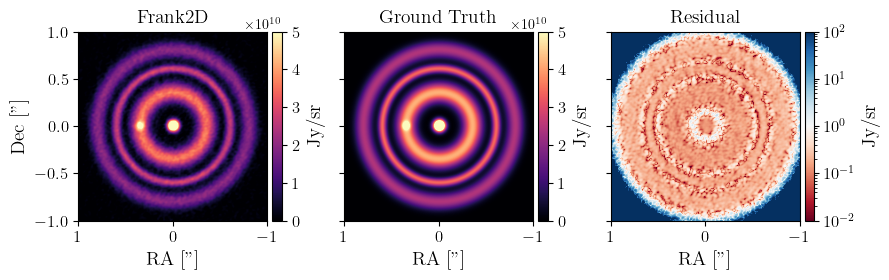

In [ ]:

from mpl_toolkits.axes_grid1 import make_axes_locatable
I_GT_final = image_jy_per_sr
I_Frank_final = frank2d.intensity_model

# --- CÁLCULO DEL RESIDUAL (Frank - Ground) ---
I_Residual = np.abs((I_Frank_final - I_GT_final)/I_GT_final)

# ==============================================================================
# 4. VISUALIZACIÓN (3 SUBPLOTS)
# ==============================================================================
# Límites para el colormap
vmax_val = max(np.nanmax(I_GT_final), np.nanmax(I_Frank_final))
vmin_val = 0

# Para el residual, usamos una escala simétrica centrada en 0
res_limit = np.max(np.abs(I_Residual))

# Configuración de figura: (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharex=True, sharey=True)
extent = [Rmax, -Rmax, -Rmax, Rmax]

# Lista de configuración para iterar
# (Datos, Título, Colormap, Vmin, Vmax)
plots_config = [
    (I_Frank_final, "Frank2D", 'magma', vmin_val, vmax_val),
    (I_GT_final, "Ground Truth", 'magma', vmin_val, vmax_val),
    (I_Residual, "Residual", 'RdBu', -res_limit, res_limit)
]

for i, (data, title, cmap, vmin, vmax) in enumerate(plots_config):
    ax = axes[i]
    
    # Plotear imagen
    # Usamos PowerNorm solo para intensidad, Linear para residual
    if i < 2: 
        norm = colors.PowerNorm(gamma=1, vmin=vmin, vmax=5e10)
    else:
        norm = colors.LogNorm(vmin = 1e-2, vmax = 1e2)

    im = ax.imshow(data, extent=extent, origin='lower', cmap=cmap, norm=norm)
    
    # Estética
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('RA ["]', fontsize=14)
    ax.set_xlim(rout, -rout)
    ax.set_ylim(-rout, rout)
    if i == 0: ax.set_ylabel('Dec ["]', fontsize=14)
    ax.grid(False)
    
    # Colorbar ajustada al tamaño del subplot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=12)
    ax.tick_params(axis='both', which='both', labelsize=12)
    cbar.set_label('Jy/sr', fontsize=14)

plt.tight_layout()
plt.show()

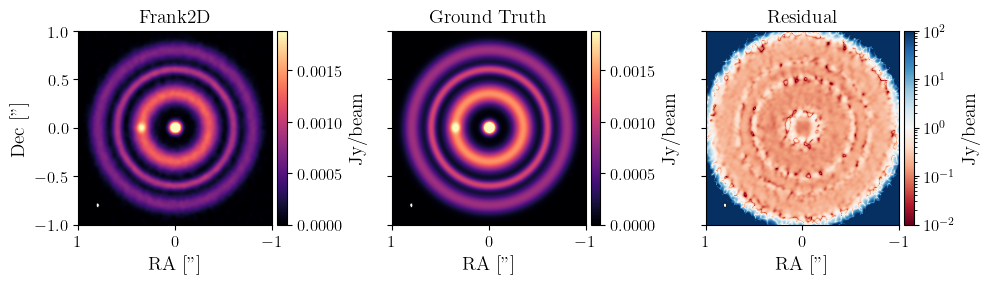

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
from scipy.ndimage import gaussian_filter

bmaj_clean = bmaj_as
bmin_clean = bmin_as
bpa_clean  = bpa_deg
fwhm_frank = 22.5e-3 


pixel_scale = (frank2d.x_grid[0][1] - frank2d.x_grid[0][0]) * rad_to_arcsec

# A) Área del Beam CLEAN
beam_area_clean = (np.pi * (bmaj_clean/rad_to_arcsec) * (bmin_clean/rad_to_arcsec)) / (4 * np.log(2))

# B) FWHM Geométrico
fwhm_clean_geom = np.sqrt(bmaj_clean * bmin_clean)

# C) Sigma para GROUND TRUTH
sigma_pixels_GT = fwhm_clean_geom / (2.35482 * pixel_scale)

# D) Sigma para FRANK2D
if fwhm_clean_geom > fwhm_frank:
    fwhm_kernel_frank = np.sqrt(fwhm_clean_geom**2 - fwhm_frank**2)
    sigma_pixels_Frank = fwhm_kernel_frank / (2.35482 * pixel_scale)
else:
    sigma_pixels_Frank = 0 

# ==============================================================================
# 3. PROCESAMIENTO E IMAGEN RESIDUAL
# ==============================================================================
gt_data = np.nan_to_num(image_jy_per_sr, nan=0.0)
frank_data = np.nan_to_num(frank2d.intensity_model, nan=0.0)

# Convolución + Conversión
I_GT_final = gaussian_filter(gt_data, sigma=sigma_pixels_GT) * beam_area_clean
I_Frank_final = gaussian_filter(frank_data, sigma=sigma_pixels_Frank) * beam_area_clean

# --- CÁLCULO DEL RESIDUAL (Frank - Ground) ---
I_Residual = np.abs((I_Frank_final - I_GT_final)/I_GT_final)

# ==============================================================================
# 4. VISUALIZACIÓN (3 SUBPLOTS)
# ==============================================================================
# Límites para el colormap
vmax_val = max(np.nanmax(I_GT_final), np.nanmax(I_Frank_final))
vmin_val = 0

# Para el residual, usamos una escala simétrica centrada en 0
res_limit = np.max(np.abs(I_Residual))

# Configuración de figura: (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)
extent = [Rmax, -Rmax, -Rmax, Rmax]

# Lista de configuración para iterar
# (Datos, Título, Colormap, Vmin, Vmax)
plots_config = [
    (I_Frank_final, "Frank2D", 'magma', vmin_val, vmax_val),
    (I_GT_final, "Ground Truth", 'magma', vmin_val, vmax_val),
    (I_Residual, "Residual", 'RdBu', -res_limit, res_limit)
]

for i, (data, title, cmap, vmin, vmax) in enumerate(plots_config):
    ax = axes[i]
    
    # Plotear imagen
    # Usamos PowerNorm solo para intensidad, Linear para residual
    if i < 2: 
        norm = colors.PowerNorm(gamma=1, vmin=vmin, vmax=vmax/2)
    else:
        norm = colors.LogNorm(vmin=1e-2, vmax=1e2)

    im = ax.imshow(data, extent=extent, origin='lower', cmap=cmap, norm=norm)
    
    # Estética
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('RA ["]', fontsize=14)
    ax.set_xlim(rout, -rout)
    ax.set_ylim(-rout, rout)
    if i == 0: ax.set_ylabel('Dec ["]', fontsize=14)
    ax.grid(False)
    
    # Beam Patch (Dibujarlo en los 3 paneles)
    beam = patches.Ellipse((rout*0.8, -rout*0.8), width=bmin_clean, height=bmaj_clean, linewidth=0.5,
                           angle=90+bpa_clean, facecolor='white', edgecolor='black', zorder=10)
    ax.add_patch(beam)
    
    # Colorbar ajustada al tamaño del subplot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=12)
    ax.tick_params(axis='both', which='both', labelsize=12)
    cbar.set_label('Jy/beam', fontsize=14)

plt.tight_layout()
plt.show()

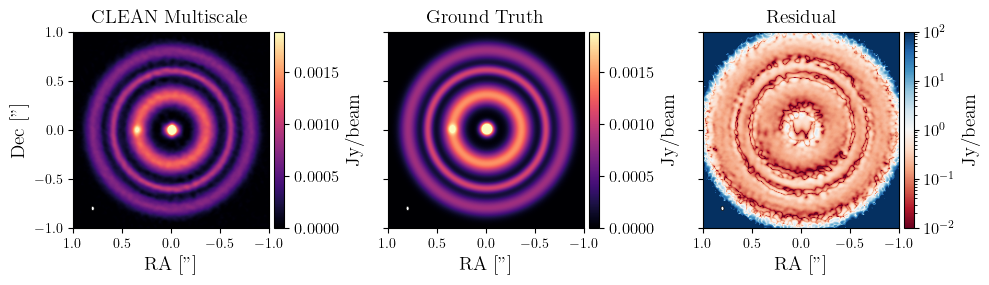

In [ ]:
pixel_scale = (frank2d.x_grid[0][1] - frank2d.x_grid[0][0]) * rad_to_arcsec

# A) Área del Beam CLEAN (Para convertir GT de Jy/sr -> Jy/beam)
beam_area_clean = (np.pi * (bmaj_clean/rad_to_arcsec) * (bmin_clean/rad_to_arcsec)) / (4 * np.log(2))

# B) Sigma para GROUND TRUTH
fwhm_clean_geom = np.sqrt(bmaj_clean * bmin_clean)
sigma_pixels_GT = fwhm_clean_geom / (2.35482 * pixel_scale)

# ==============================================================================
# 2. PREPARACIÓN DE IMÁGENES
# ==============================================================================
# A) Ground Truth: Se convoluciona para simular la observación
gt_data = np.nan_to_num(image_jy_per_sr, nan=0.0)
I_GT_final = gaussian_filter(gt_data, sigma=sigma_pixels_GT) * beam_area_clean

# B) CLEAN: Se usa directamente la imagen output del clean
I_CLEAN_final = np.nan_to_num(img, nan=0.0) 

# C) Residual: CLEAN - Ground Truth
I_Residual = np.abs((I_CLEAN_final - I_GT_final)/I_GT_final)

# ==============================================================================
# 3. VISUALIZACIÓN (3 SUBPLOTS)
# ==============================================================================
# Rango dinámico compartido para intensidad
vmax_val = max(np.nanmax(I_GT_final), np.nanmax(I_CLEAN_final))
vmin_val = 0

# Rango simétrico para el residual
res_limit = np.max(np.abs(I_Residual))

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)
extent = [Rmax, -Rmax, -Rmax, Rmax]

# Configuración de los paneles
plots_config = [
    (I_CLEAN_final, "CLEAN Multiscale", 'magma', vmin_val, vmax_val),
    (I_GT_final, "Ground Truth", 'magma', vmin_val, vmax_val),
    (I_Residual, "Residual", 'RdBu', -res_limit, res_limit)
]

for i, (data, title, cmap, vmin, vmax) in enumerate(plots_config):
    ax = axes[i]
    
    # Selección de normalización (Log/Power para imagen, Linear para residual)
    if i < 2: 
        norm = colors.PowerNorm(gamma=1, vmin=vmin, vmax=vmax/2)
    else:
        norm = colors.LogNorm(vmin=1e-2, vmax=1e2)

    im = ax.imshow(data, extent=extent, origin='lower', cmap=cmap, norm=norm)
    
    # Estética
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('RA ["]', fontsize=14)
    ax.set_xlim(rout, -rout)
    ax.set_ylim(-rout, rout)

    if i == 0: ax.set_ylabel('Dec ["]', fontsize=14)
    ax.grid(False)
    
    # Beam Patch (Visualización del beam en las esquinas)
    beam = patches.Ellipse((rout*0.8, -rout*0.8), width=bmin_clean, height=bmaj_clean, linewidth=0.5,
                           angle=90+bpa_clean, facecolor='white', edgecolor='black', zorder=10)
    ax.add_patch(beam)
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Jy/beam', fontsize=14)

plt.tight_layout()
plt.show()